**import libraries**

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df = pd.read_csv('../data/diabetic_data.csv')

**Duplicate**

In [52]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


**missing values**

In [53]:
df.replace("?", np.nan, inplace=True)
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [54]:
missing_percent = (
    df.isnull()
      .mean()
      *100
)

missing_percent = missing_percent.sort_values(ascending=False)

missing_percent = missing_percent[missing_percent >0]

missing_percent

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

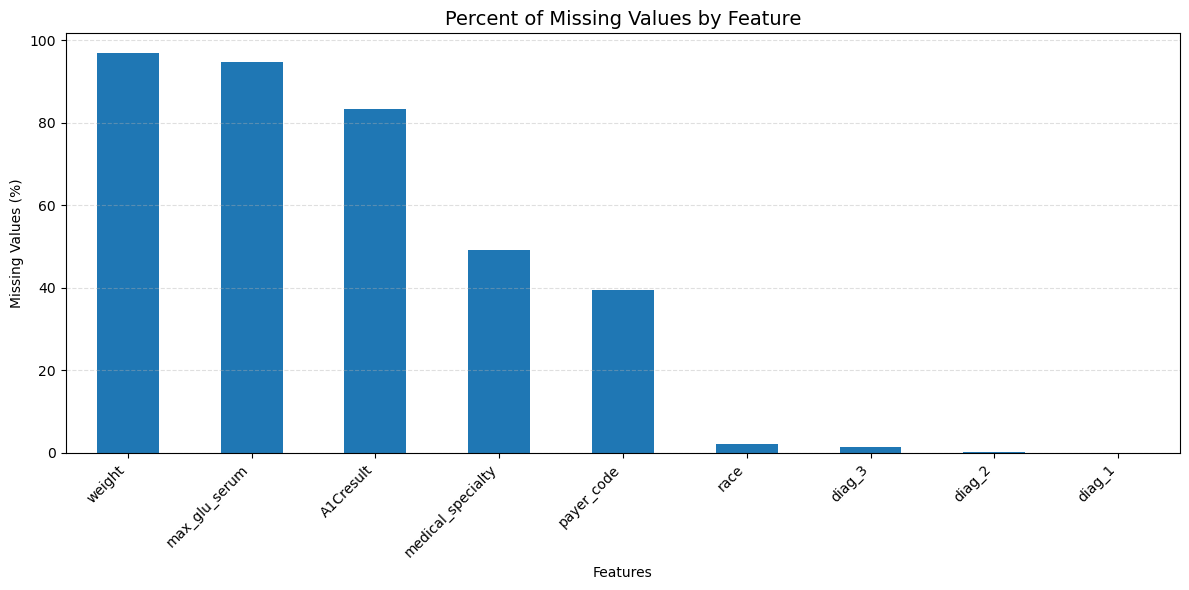

In [58]:
plt.figure(figsize=(12,6))

missing_percent.plot(kind="bar")

plt.title("Percent of Missing Values by Feature", fontsize=14)

plt.xlabel("Features")

plt.ylabel("Missing Values (%)")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

### Observation

The dataset contains several features with missing values.

The `weight` feature has an extremely high percentage of missing values (approximately 97%), making it unsuitable for reliable imputation.

Similarly, `medical_specialty` and `payer_code` contain substantial missing data and will be considered for removal during the cleaning process.

The remaining features contain relatively few missing values and will be handled individually in later preprocessing steps.

**Invalid Values**

In [55]:
df.drop(columns=[
    "encounter_id",
    "weight",
    "max_glu_serum",
    "A1Cresult",
    "medical_specialty",
    "payer_code",
    "patient_nbr"
], inplace=True)

**Category Inspection**

In [56]:
for col in df.select_dtypes("object"):

    print(col)

    print(df[col].value_counts())

    print("-"*40)

race
race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64
----------------------------------------
gender
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64
----------------------------------------
age
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64
----------------------------------------
diag_1
diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
       ... 
817       1
61        1
148       1
870       1
V51       1
Name: count, Length: 716, dtype: int64
----------------------------------------
diag_2
diag_2
276     6752
428     6662
250     6071
427     5036
401     3736
        ... 
232        1
908        1
52         1
E817       1
927        1
Name

**save data**

In [61]:
df.to_csv(
    "../data/processed/clean_data.csv",
    index=False
)

## Summary of Changes

The following data cleaning steps were completed in this notebook:

- Replaced all `"?"` values with `NaN`.
- Analyzed the percentage of missing values across all features.
- Removed features with excessive missing values:
  - `weight`
  - `payer_code`
  - `medical_specialty`
- Removed identifier columns:
  - `encounter_id`
  - `patient_nbr`
- Checked for duplicate records.
- Verified data types after cleaning.
- Saved the cleaned dataset for subsequent analysis.